# 01 — Data Quality (P0)

**What this notebook answers**

- Are all expected venue × product × event streams flowing?
- What is the per-stream message rate? Any silent gaps?
- How big is the local-vs-exchange clock skew? Does it look stable?
- Schema sanity: NaN/null fields, duplicate sequence numbers, weird prices.

This is the gate-keeper. If anything below looks wrong, **do not** trust higher-phase notebooks until fixed.

In [1]:
from hlanalysis.analysis import duck, glob_for, load_df, set_mpl_defaults, fmt_ts
import pandas as pd, numpy as np, matplotlib.pyplot as plt

set_mpl_defaults()
ALL = glob_for()  # everything
con = duck()
print('parquet root :', glob_for().split('venue=')[0])

parquet root : /Users/shreypaharia/Documents/Projects/Trading/HLAnalysis/data/


## 1. Coverage matrix

Row counts and time-bounds per (venue, product_type, event, symbol). Look for unexpected zeros and short windows.

In [2]:
cov = load_df(f'''
SELECT venue, product_type, event, symbol,
       count(*)                          AS rows,
       min(exchange_ts)                  AS t0_ns,
       max(exchange_ts)                  AS t1_ns,
       (max(exchange_ts)-min(exchange_ts))/1e9/3600.0 AS hours
FROM read_parquet('{ALL}', hive_partitioning=true)
WHERE event NOT IN ('health','market_meta')
GROUP BY 1,2,3,4
ORDER BY 1,2,3,4
''')
cov['t0'] = cov.t0_ns.map(fmt_ts)
cov['t1'] = cov.t1_ns.map(fmt_ts)
cov['rows_per_min'] = cov['rows'] / (cov['hours']*60).clip(lower=1e-9)
cov[['venue','product_type','event','symbol','rows','rows_per_min','hours','t0','t1']]

,venue,product_type,event,symbol,rows,rows_per_min,hours,t0,t1
0,binance,perp,bbo,BTCUSDT,16136,6433.512529,0.041802,2026-05-06 20:55:28,2026-05-06 20:57:59
1,binance,perp,book_snapshot,BTCUSDT,1417,564.935712,0.041804,2026-05-06 20:55:28,2026-05-06 20:57:59
2,binance,perp,funding,BTCUSDT,45,18.494037,0.040554,2026-05-06 20:55:30,2026-05-06 20:57:56
3,binance,perp,mark,BTCUSDT,45,18.494037,0.040554,2026-05-06 20:55:30,2026-05-06 20:57:56
4,binance,perp,trade,BTCUSDT,2434,972.912475,0.041696,2026-05-06 20:55:28,2026-05-06 20:57:58
5,binance,spot,bbo,BTCUSDT,7680,3066.733764,0.041738,2026-05-06 20:55:28,2026-05-06 20:57:58
6,binance,spot,book_snapshot,BTCUSDT,1506,600.384681,0.041807,2026-05-06 20:55:28,2026-05-06 20:57:59
7,binance,spot,trade,BTCUSDT,1620,646.904575,0.041737,2026-05-06 20:55:28,2026-05-06 20:57:58
8,hyperliquid,perp,bbo,BTC,12,4.901994,0.040800,2026-05-06 20:55:30,2026-05-06 20:57:57
9,hyperliquid,perp,book_snapshot,BTC,85,34.249105,0.041364,2026-05-06 20:55:28,2026-05-06 20:57:57


## 2. Per-minute message rate (top streams)

A flat curve = healthy. Sudden cliffs = WS reconnects, geo-blocks, or exchange-side incidents. Compare visually across venues.

IOException: IO Error: No files found that match the pattern "/Users/shreypaharia/Documents/Projects/Trading/HLAnalysis/data/venue=hyperliquid/product_type=prediction_binary/mechanism=*/event=bbo/symbol=#30/date=*/hour=*/*.parquet"

LINE 4:         FROM read_parquet('/Users/shreypaharia/Documents/Projects/Trading...
                     ^

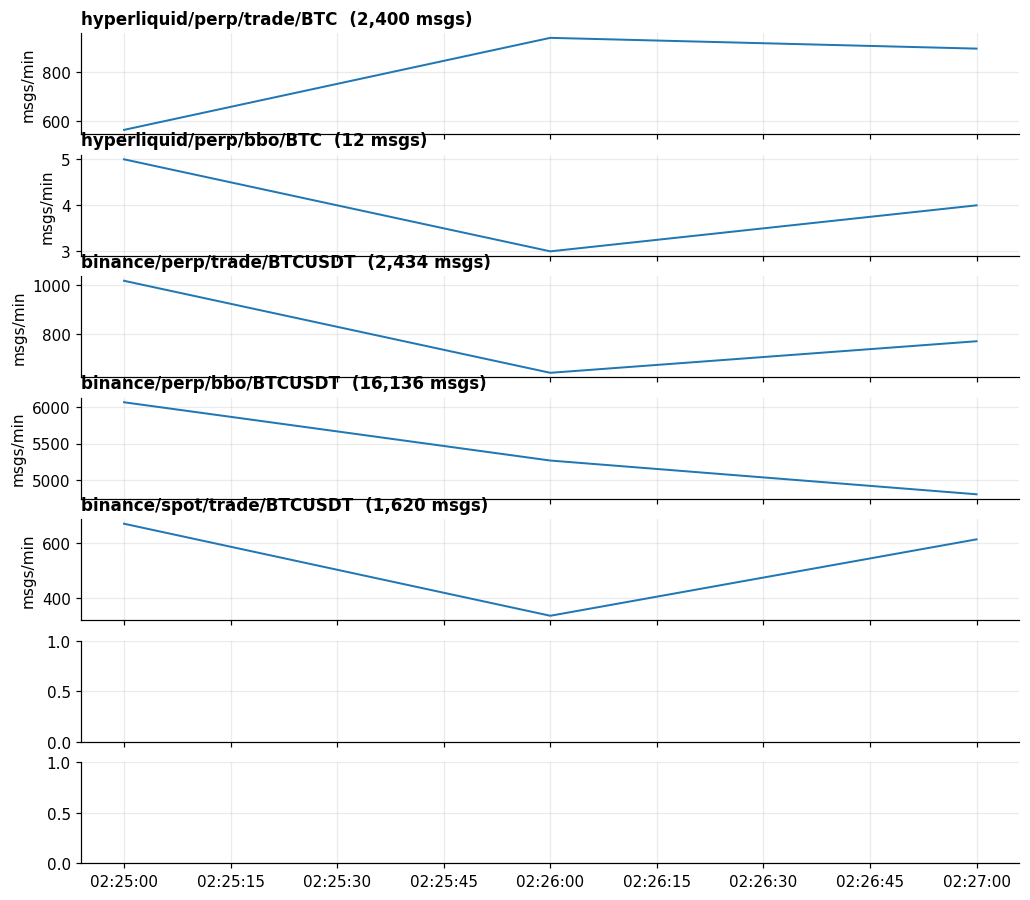

In [3]:
streams = [
    ('hyperliquid','perp','trade','BTC'),
    ('hyperliquid','perp','bbo','BTC'),
    ('binance','perp','trade','BTCUSDT'),
    ('binance','perp','bbo','BTCUSDT'),
    ('binance','spot','trade','BTCUSDT'),
    ('hyperliquid','prediction_binary','bbo','#30'),
    ('hyperliquid','prediction_binary','bbo','#31'),
]

fig, axes = plt.subplots(len(streams), 1, figsize=(11, 1.4*len(streams)), sharex=True)
for ax, (v, p, e, s) in zip(axes, streams):
    g = glob_for(venue=v, product_type=p, event=e, symbol=s)
    df = load_df(f'''
        SELECT date_trunc('minute', to_timestamp(exchange_ts/1e9)) AS minute,
               count(*) AS msgs
        FROM read_parquet('{g}', hive_partitioning=true)
        GROUP BY 1 ORDER BY 1
    ''')
    if df.empty:
        ax.set_title(f'{v}/{p}/{e}/{s}  (no data)', loc='left'); continue
    ax.plot(df.minute, df.msgs)
    ax.set_title(f'{v}/{p}/{e}/{s}  ({df.msgs.sum():,} msgs)', loc='left')
    ax.set_ylabel('msgs/min')
plt.tight_layout(); plt.show()

## 3. Inter-arrival gaps

For each high-frequency stream, the 99.9th percentile inter-arrival should be << 5s. Anything bigger is a stall to investigate.

In [ ]:
def gap_stats(venue, product_type, event, symbol):
    g = glob_for(venue=venue, product_type=product_type, event=event, symbol=symbol)
    df = load_df(f'''
      WITH t AS (
        SELECT exchange_ts FROM read_parquet('{g}', hive_partitioning=true)
        ORDER BY exchange_ts
      ),
      d AS (
        SELECT (exchange_ts - lag(exchange_ts) OVER ()) / 1e6 AS gap_ms FROM t
      )
      SELECT
        count(*) AS n,
        approx_quantile(gap_ms, 0.50) AS p50_ms,
        approx_quantile(gap_ms, 0.99) AS p99_ms,
        approx_quantile(gap_ms, 0.999) AS p999_ms,
        max(gap_ms) AS max_ms
      FROM d WHERE gap_ms IS NOT NULL
    ''')
    df.insert(0,'stream', f'{venue}/{product_type}/{event}/{symbol}')
    return df

rows = [gap_stats(*s) for s in streams]
pd.concat(rows, ignore_index=True)

,stream,n,p50_ms,p99_ms,p999_ms,max_ms
0,hyperliquid/perp/trade/BTC,427776,0.000000,1017.501808,1823.336196,1492607.0
1,hyperliquid/perp/bbo/BTC,489493,37.772102,416.120035,854.842944,1499612.0
2,binance/perp/trade/BTCUSDT,2877014,0.000000,267.226227,741.601185,1202765.0
3,binance/perp/bbo/BTCUSDT,20056450,0.000000,39.933349,144.588278,1202155.0
4,binance/spot/trade/BTCUSDT,1984590,0.000000,474.183433,1314.896325,1202961.0
5,hyperliquid/prediction_binary/bbo/#30,47735,51.135054,9454.687591,33920.834876,2113775.0
6,hyperliquid/prediction_binary/bbo/#31,33274,54.727091,13864.436684,39889.433503,2210150.0


## 4. Clock skew  (local_recv - exchange_ts)

Latency to exchange + our wall-clock drift. Two signals:
- **median**: pure transport latency (ok if ~50–250 ms HL/Binance from your IP).
- **dispersion / drift**: local clock running slow/fast → fix with ntp.

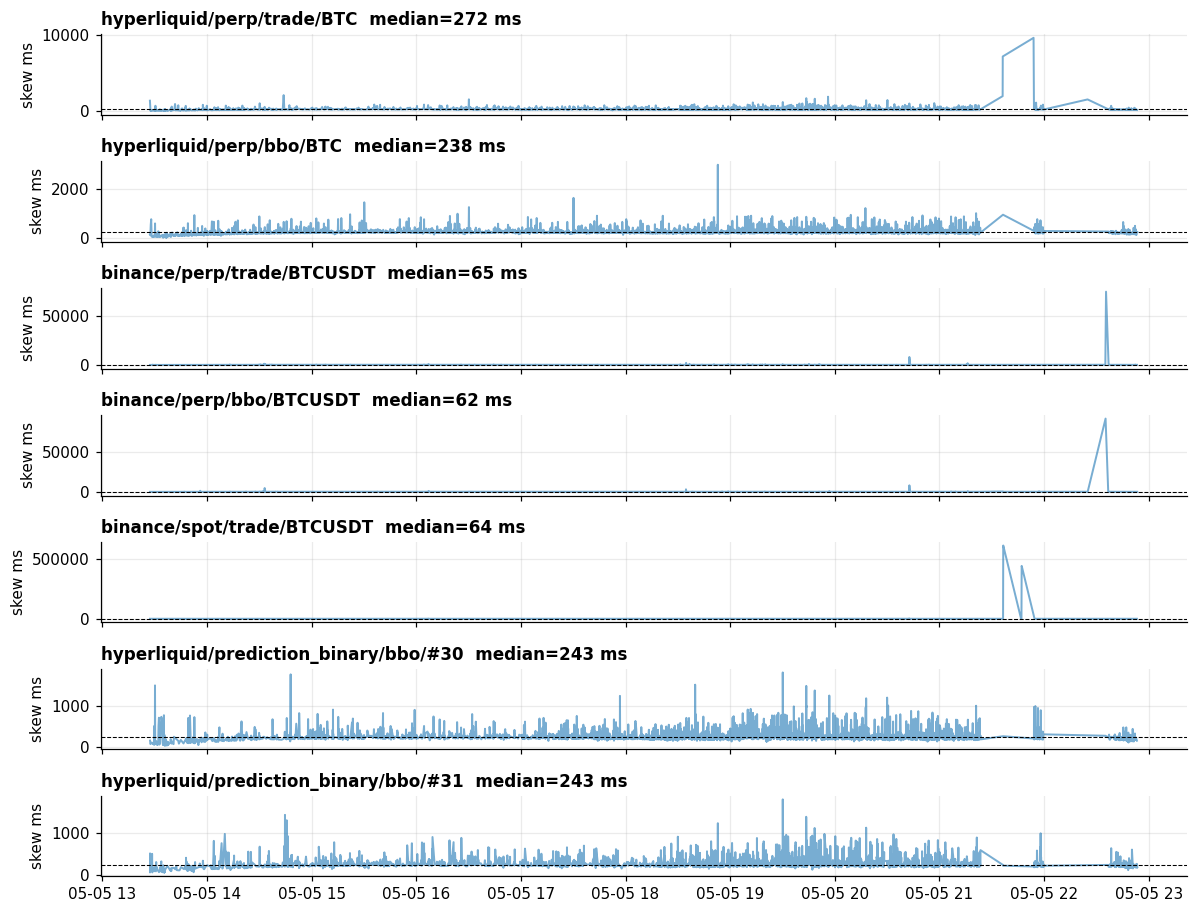

In [ ]:
fig, axes = plt.subplots(len(streams), 1, figsize=(11, 1.2*len(streams)), sharex=True)
for ax, (v, p, e, s) in zip(axes, streams):
    g = glob_for(venue=v, product_type=p, event=e, symbol=s)
    df = load_df(f'''
        SELECT to_timestamp(exchange_ts/1e9) AS t,
               (local_recv_ts - exchange_ts)/1e6 AS skew_ms
        FROM read_parquet('{g}', hive_partitioning=true)
        ORDER BY t
    ''')
    if df.empty:
        ax.set_title(f'{v}/{p}/{e}/{s}  (no data)', loc='left'); continue
    df = df.iloc[::max(1, len(df)//4000)]
    ax.plot(df.t, df.skew_ms, alpha=0.6)
    med = df.skew_ms.median()
    ax.axhline(med, color='k', ls='--', lw=0.7)
    ax.set_title(f'{v}/{p}/{e}/{s}  median={med:.0f} ms', loc='left')
    ax.set_ylabel('skew ms')
plt.tight_layout(); plt.show()

## 5. Health log

Subscribed / reconnect / outcome-rolled events. A clean run shows a small set of `subscribed` lines at startup and not much else.

In [ ]:
hg = glob_for(event='health')
load_df(f'''
SELECT venue, product_type, kind, detail, to_timestamp(exchange_ts/1e9) AS t
FROM read_parquet('{hg}', hive_partitioning=true)
ORDER BY exchange_ts
''').tail(60)

,venue,product_type,kind,detail,t
222,hyperliquid,perp,subscribed,"{""method"": ""subscribe"", ""subscription"": {""type...",2026-05-05 22:24:59.731684+05:30
223,hyperliquid,perp,subscribed,"{""method"": ""subscribe"", ""subscription"": {""type...",2026-05-05 22:24:59.731771+05:30
224,binance,perp,connected/spot,,2026-05-05 22:25:00.630972+05:30
225,binance,perp,subscribed/spot,"{""result"": null, ""id"": 1}",2026-05-05 22:25:00.789863+05:30
226,binance,perp,reconnect/perp,no close frame received or sent,2026-05-05 22:35:05.580162+05:30
227,binance,perp,connected/perp,,2026-05-05 22:35:07.076174+05:30
228,binance,perp,subscribed/perp,"{""result"": null, ""id"": 1}",2026-05-05 22:35:07.240547+05:30
229,hyperliquid,perp,connected,ws open,2026-05-05 22:35:11.800639+05:30
230,hyperliquid,perp,subscribed,"{""method"": ""subscribe"", ""subscription"": {""type...",2026-05-05 22:35:11.966907+05:30
231,hyperliquid,perp,subscribed,"{""method"": ""subscribe"", ""subscription"": {""type...",2026-05-05 22:35:12.222250+05:30


## 6. Schema sanity — NaNs, dupes, weird values

Sanity-check that no field that should be present is null, and that no obviously-impossible values (e.g. negative size) leaked in.

In [ ]:
# Trades: nulls, sign / size / price bounds
sane = load_df(f'''
SELECT venue, symbol,
       count(*) AS n,
       sum(price <= 0)          AS bad_px,
       sum(size <= 0)           AS bad_sz,
       sum(side='unknown')      AS unknown_side,
       count(DISTINCT trade_id) AS distinct_ids
FROM read_parquet('{glob_for(event="trade")}', hive_partitioning=true)
GROUP BY 1,2 ORDER BY 1,2
''')
sane

,venue,symbol,n,bad_px,bad_sz,unknown_side,distinct_ids
0,binance,BTCUSDT,4861606,6793.0,6793.0,0.0,2436779
1,hyperliquid,#30,22045,0.0,0.0,0.0,11014
2,hyperliquid,#31,22045,0.0,0.0,0.0,11014
3,hyperliquid,BTC,427777,0.0,0.0,0.0,214277


In [ ]:
# BBO: crossed / locked books should be ~0
xb = load_df(f'''
SELECT venue, symbol,
       count(*) AS n,
       sum(bid_px >= ask_px) AS crossed_or_locked,
       avg((ask_px-bid_px)/((ask_px+bid_px)/2)) AS avg_rel_spread
FROM read_parquet('{glob_for(event="bbo")}', hive_partitioning=true)
WHERE bid_px IS NOT NULL AND ask_px IS NOT NULL AND bid_px>0 AND ask_px>0
GROUP BY 1,2 ORDER BY 1,2
''')
xb

,venue,symbol,n,crossed_or_locked,avg_rel_spread
0,binance,BTCUSDT,27563039,0.0,0.000001
1,hyperliquid,#30,47736,0.0,0.006166
2,hyperliquid,#31,33275,0.0,0.012537
3,hyperliquid,BTC,489494,0.0,0.000014


## 7. Verdict

Read this off the cells above:
- Coverage row matches expectation? (HL BTC perp, HL UBTC spot if present, HL #30 #31, Binance perp + spot — all should have rows)
- No streams with `rows == 0` for active subscriptions
- p999 inter-arrival under ~5 s on every stream
- Clock skew bounded and not drifting (>>1 s drift over 1 hr ⇒ ntp the host)
- `crossed_or_locked` ≈ 0 on all BBO streams

If any check fails, fix recorder before consuming downstream notebooks.